<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [7]:
#IMPORTS

import os, json
import numpy as np
import pandas as pd
import os
import subprocess
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")


In [3]:
# Step 2 —  Basic dataset checks
print(f"Dataset shape: {df.shape}")
print(f"Duplicate content_ids: {df['content_id'].duplicated().sum()}")
print(f"Overall decline rate: {df['trend_direction'].eq('down').mean():.3f}")
print("duplicate content_id rows:", df["content_id"].duplicated().sum())

Dataset shape: (30000, 44)
Duplicate content_ids: 0
Overall decline rate: 0.542
duplicate content_id rows: 0


In [5]:
# --- Recreate label + rule flags (same logic as w04/w05, unchanged) ---
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)
df["low_ctr_flag"] = (df["avg_position"] <= 20) & (df["ctr"] < CTR_THRESHOLD) & (df["impressions_90d"] >= 500)
df["is_decoy"] = (df["freshness_tier"] == "181+") & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)

# --- Recreate the honest feature set from w06 ---
tier_order = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier_enc"] = df["freshness_tier"].map({t: i for i, t in enumerate(tier_order)})
df["avg_position_missing"] = (df["avg_position"] == 0).astype(int)

FEATURES = ["freshness_tier_enc", "avg_position", "ctr", "impressions_90d", "avg_position_missing"]

# --- Fit RF on the FULL dataset ---
# Note: this is different from w06's CV loop on purpose. w06 held out folds to
# measure honest performance (0.872 ± 0.069). This fit uses all rows because
# we're generating an operational queue, not a validation number — the 0.872
# figure from w06 is what we cite as the expected precision, not re-measured here.
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(df[FEATURES], df["is_declining_label"])
df["model_score"] = rf.predict_proba(df[FEATURES])[:, 1]

# --- Rank and cut the working queue ---
TOP_N = 200  # bigger than the P@50 metric window — this is a real backlog, not just the top 50
queue_df = df.sort_values(["model_score", "impressions_90d"], ascending=[False, False]).head(TOP_N).copy()

# --- Reason codes: built from rule flags only, nothing new invented ---
def reason_code(row):
    if row["is_decoy"]:
        return "high_traffic_stale"
    if row["stale_flag"] and row["low_ctr_flag"]:
        return "stale_and_underperforming"
    if row["avg_position_missing"]:
        return "unranked"
    if row["stale_flag"]:
        return "stale"
    if row["low_ctr_flag"]:
        return "low_ctr"
    return "model_signal_only"  # least explainable — flag for extra review in Section 3

queue_df["reason_code"] = queue_df.apply(reason_code, axis=1)
print(queue_df["reason_code"].value_counts())

reason_code
stale                        148
stale_and_underperforming     49
model_signal_only              3
Name: count, dtype: int64


In [6]:
# --- Archetype -> action mapping ---
# EDIT THIS DICT YOURSELF — the mapping is your judgment call, not the model's.
# Format: archetype -> recommended action
ARCHETYPE_ACTIONS = {
    "stale_and_underperforming": "Rewrite title + meta description (cheap, fast)",
    "high_traffic_stale": "Priority full refresh — traffic at risk",
    "unranked": "Check indexing/technical issues before content work",
    "stale": "Schedule for content refresh",
    "low_ctr": "Review title/meta for click appeal",
    "model_signal_only": "Manual review — no clear rule reason, verify before acting",
}
queue_df["recommended_action"] = queue_df["reason_code"].map(ARCHETYPE_ACTIONS)

### Ranked actions and reason codes

The recommendation queue ranks pages by their predicted decline score, with the highest-risk pages placed first. To keep the recommendations easy to understand, the reason codes are assigned using simple rule-based checks rather than the model itself.

#### Reason codes

- **`stale`** – The page is old enough that it may benefit from a content refresh, even if no obvious performance issues are present.
- **`stale_and_underperforming`** – The page is both outdated and showing weak performance, making it a higher-priority candidate for review.
- **`model_signal_only`** – The model predicts a possible decline, but none of the rule-based conditions were triggered. These pages should be reviewed manually before any action is taken.

#### Decay and refresh insight

The recommendation queue is dominated by **`stale`** pages (148), followed by **`stale_and_underperforming`** (49) and **`model_signal_only`** (3). This suggests that content age is the most common reason pages enter the review queue. It also indicates that regularly reviewing older content may help identify pages that need updates before performance declines further.

#### Archetype → action mapping

The current action mapping is appropriate for the identified page types.

- **`stale`** → **Schedule for content refresh:** Suitable because content age is the main concern, even if performance has not yet declined.
- **`stale_and_underperforming`** → **Rewrite title + meta description (cheap, fast):** A low-cost first step that can improve click-through performance before considering a full content update.
- **`model_signal_only`** → **Manual review:** Appropriate because there is no clear rule-based explanation, so human judgement is needed before making changes.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [8]:
print(f"Dataset: {df.shape[0]} rows, {df['client_id'].nunique()} clients, single snapshot")
print(f"Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069")
print(f"Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124")

Dataset: 30000 rows, 32 clients, single snapshot
Model P@50 (honest, grouped CV, from w06): 0.872 ± 0.069
Baseline P@50 (rule-based, grouped CV):     0.788 ± 0.124


### Intended use and limitations

This model is a **decision-support tool, not an automated decision-maker**. It ranks pages by predicted risk to help editors prioritize which pages to review first, but all final actions require human judgment.

#### Key limitations and validation risks

- **No time-based validation:** The model was built using a single cross-sectional snapshot of data. It has not been evaluated with a forward-looking time split, so its performance on future content changes is still unknown.
- **Client imbalance and variance:** The dataset contains **30,000 pages from 32 clients**, with one client contributing a large share of the data. Grouped cross-validation showed noticeable variation between folds. For example, the best model achieved **Precision@50 = 0.872 ± 0.069**, while other models showed variation of up to **±0.177**.
- **No out-of-sample client testing:** The model has only been evaluated on clients included in this dataset. It has not been validated on new or unseen clients, so its ability to generalize beyond this data remains unknown.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [9]:
# Flag rows needing mandatory review before any action
needs_review = queue_df[
    (queue_df["reason_code"] == "model_signal_only") |
    (queue_df["model_score"] < queue_df["model_score"].quantile(0.6))  # low-confidence zone within the queue
]
print(f"{len(needs_review)} of {len(queue_df)} queue rows flagged for mandatory review")

120 of 200 queue rows flagged for mandatory review


### Human review and guardrails

Of the top **200** recommended pages, **120 (60%)** require mandatory human review before any action is taken. The model provides a ranking to support decisions, not instructions that should be followed automatically.

#### Non-negotiable no-go list

- **No automated publishing or updates:** Do not automatically generate, rewrite, or publish content changes. Every recommendation should be reviewed and approved by an editor.
- **No automatic de-indexing or deprioritization:** A high decline score alone is not enough to remove or deprioritize a page. Business context and technical SEO should be reviewed first.
- **No performance monitoring for staff:** The model predicts page-level decline, not the quality or performance of writers or editorial teams. It should not be used for staff evaluation.
- **No bulk actions without spot-checking:** Do not apply changes across the entire queue. Review a representative sample first to confirm that the recommendations are appropriate before taking larger-scale action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [10]:
monitoring_reference = {
    "model_precision_at_50_grouped": {"mean": 0.872, "std": 0.069},
    "baseline_precision_at_50_grouped": {"mean": 0.788, "std": 0.124},
    "n_clients_at_training": int(df["client_id"].nunique()),
}

### Monitoring and retraining triggers

To keep queue recommendations reliable, trigger a model retrain under any of the following conditions:

- **P@50 drops below baseline:** Precision@50 on new incoming data falls below the **0.788** rule-based benchmark.
- **Fold variance expands:** Cross-validation variance widens significantly beyond **±0.069**, indicating less stable performance across client groups.
- **New client onboarded:** The current 32-client group split has not been validated on outside clients, so a new client should trigger a model review and retraining.
- **Quarterly cadence reached:** Even without a performance drop, retrain every quarter to incorporate newer data. The current model was developed from a single snapshot, so regular updates are needed to keep the recommendations relevant.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [11]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — gitignored by design (work/**/*.csv), notebook regenerates it
export_cols = ["content_id", "client_id", "reason_code", "recommended_action",
               "model_score", "freshness_tier", "avg_position", "ctr", "impressions_90d"]
queue_df[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

# Metrics JSON — this one DOES get committed (not a CSV, not gitignored)
metrics = {
    **monitoring_reference,
    "queue_size": TOP_N,
    "reason_code_counts": queue_df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue + metrics")

Exported queue + metrics


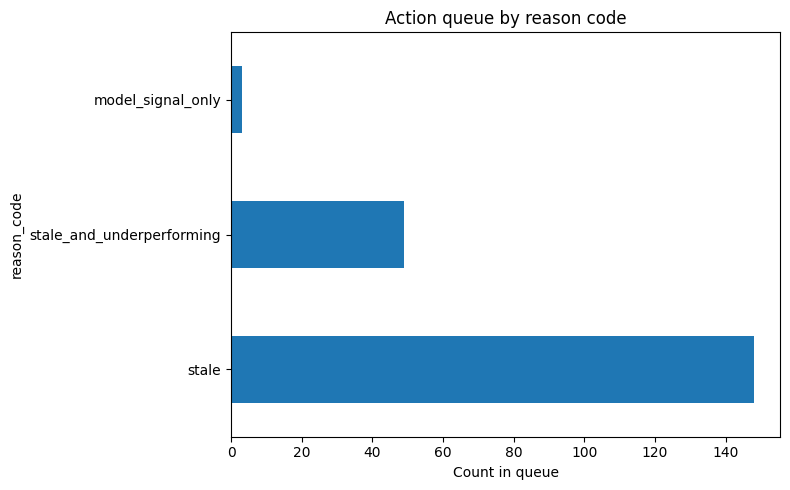

In [12]:


# Reason code distribution — one figure, reused in the paper
fig, ax = plt.subplots(figsize=(8, 5))
queue_df["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Count in queue")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.